Name - Kuvam Sharma

Student ID - iitp_aiml_2506443

Standard implementation patterns for model tuning (GridSearchCV, StratifiedKFold, Pipeline usage) and experiment tracking (MLflow logging structure) were inspired by official scikit-learn and MLflow documentation. All experimentation, model comparisons, and performance analysis were conducted independently.

# Importing train & test data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib

X_train = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/X_train.pkl")
X_test = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/X_test.pkl")
y_train = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/y_train.pkl")
y_test = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/y_test.pkl")


Imported Training & Test datasets are already scaled

# Model Development (Baseline Models)

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.0 MB/s eta 0:00:00


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
import mlflow
import mlflow.sklearn

<h3>Fitting training data to a Logistic Regression baseline model

In [ ]:
lr_pipeline = Pipeline([('classifier', LogisticRegression(random_state=42))
])

lr_pipeline.fit(X_train, y_train)
train_score_lr = lr_pipeline.score(X_train,y_train)
print(f"Training Accuracy of Logistic Regression: {train_score_lr} ")

Training Accuracy of Logistic Regression: 0.81 


<h3>Testing the accuracy of Logistic Regression baseline model

In [ ]:
y_pred_lr = lr_pipeline.predict(X_test)
accuracy_score_lr = accuracy_score(y_pred_lr, y_test)
print(f"Test Accuracy of Logistic Regression: {accuracy_score_lr}")

Test Accuracy of Logistic Regression: 0.795


In [ ]:
report_lr = classification_report(y_pred_lr, y_test)

print(report_lr)

              precision    recall  f1-score   support

           0       0.87      0.81      0.84       130
           1       0.68      0.77      0.72        70

    accuracy                           0.80       200
   macro avg       0.78      0.79      0.78       200
weighted avg       0.80      0.80      0.80       200



<h3>Fitting training data to a Decision Tree Classifier baseline model

In [ ]:
dt_pipeline = Pipeline([('classifier',
                         DecisionTreeClassifier(random_state = 42))])

dt_pipeline.fit(X_train, y_train)
train_score_dt = dt_pipeline.score(X_train,y_train)
print(f"Training Accuracy of Decision Tree Classifier: {train_score_dt} ")

Training Accuracy of Decision Tree Classifier: 1.0 


<h3>Testing the accuracy of Decision Tree Classifier baseline model

In [ ]:
y_pred_dt = dt_pipeline.predict(X_test)
accuracy_score_dt = accuracy_score(y_pred_dt, y_test)
print(f"Test Accuracy of  Decision Tree Classifier: {accuracy_score_dt}")

Test Accuracy of  Decision Tree Classifier: 0.805


In [ ]:
report_dt = classification_report(y_pred_dt, y_test)

print(report_dt)

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       120
           1       0.76      0.75      0.75        80

    accuracy                           0.81       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.81      0.80       200



<h3>Fitting training data to a Random Forrest Classifier baseline model

In [ ]:
rf_pipeline = Pipeline([('classifier',
                         RandomForestClassifier(random_state = 42))])

rf_pipeline.fit(X_train, y_train)
train_score_rf = rf_pipeline.score(X_train,y_train)
print(f"Training Accuracy of Random Forest Classifier: {train_score_rf} ")

Training Accuracy of Random Forest Classifier: 1.0 


<h3>Testing the accuracy of Random Forest baseline model

In [ ]:
y_pred_rf = rf_pipeline.predict(X_test)
accuracy_score_rf = accuracy_score(y_pred_rf, y_test)
print(f"Test Accuracy of Random Forest Classifier: {accuracy_score_rf} ")

Test Accuracy of Random Forest Classifier: 0.85 


In [ ]:
report_rf = classification_report(y_pred_rf, y_test)

print(report_rf)

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       125
           1       0.78      0.83      0.81        75

    accuracy                           0.85       200
   macro avg       0.84      0.85      0.84       200
weighted avg       0.85      0.85      0.85       200



<h3>Fitting training data to a XG Boost model

In [ ]:
xgb_pipeline = Pipeline([('classifier',
                          XGBClassifier(random_state = 42,
                                        eval_metric='logloss'))])

xgb_pipeline.fit(X_train, y_train)
train_score_xgb = xgb_pipeline.score(X_train,y_train)
print(f"Training Accuracy of XGBoost Classifier: {train_score_xgb} ")

Training Accuracy of XGBoost Classifier: 1.0 


<h3>Testing the accuracy of XG Boost baseline model

In [ ]:
y_pred_xgb = xgb_pipeline.predict(X_test)
accuracy_score_xgb = accuracy_score(y_pred_xgb, y_test)
print(f"Test Accuracy of XGBoost Classifier: {accuracy_score_xgb} ")

Test Accuracy of XGBoost Classifier: 0.83 


In [ ]:
report_xgb = classification_report(y_pred_xgb, y_test)

print(report_xgb)

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       127
           1       0.75      0.81      0.78        73

    accuracy                           0.83       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.83      0.83      0.83       200



# Hyperparameter Tuning

<h2>Why Hyperparameter Tuning is Necessary
Hyperparameter tuning is performed to improve model generalization.   

Default parameters often lead to either underfitting or overfitting.  

By systematically exploring different configurations using cross-validation, the goal is to find a balance between model complexity and predictive performance.

<h2>Logistic Regression – Grid Search with Normal CV

In this step, GridSearchCV is applied to Logistic Regression using standard K-Fold cross-validation.

The goal is to identify the

optimal
regularization strength (C)

penalty type

solver combination.

Normal K-Fold splits the data into equal partitions without explicitly preserving class proportions.

This provides a general estimate of performance across multiple splits.

In [ ]:
param_grid = [
    # L2 with lbfgs
    {'classifier__penalty': ['l2', None],
     'classifier__solver': ['lbfgs'],
     'classifier__C': [0.01, 0.1, 1, 10]},

    # L1 with liblinear
    {'classifier__penalty': ['l1','l2'],
     'classifier__solver': ['liblinear'],
     'classifier__C': [0.01, 0.1, 1, 10]},

    # ElasticNet with saga
    {'classifier__penalty': ['elasticnet','l1','l2'],
     'classifier__solver': ['saga'],
     'classifier__C': [0.01, 0.1, 1],
     'classifier__l1_ratio': [0.2, 0.5, 0.8]}
]
grid_search_lr = GridSearchCV(
    lr_pipeline,
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_lr.fit(X_train, y_train)
print(f"Best params: {grid_search_lr.best_params_}")
print(f"Best CV score: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 43 candidates, totalling 215 fits
Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV score: 0.7438


<h2>Logistic Regression – Normal CV Best Parameters & Test Accuracy

After identifying the best hyperparameters using normal cross-validation, the model is retrained on the full training set and evaluated on the test set.

The training score reflects how well the model fits known data, while the test accuracy indicates how well it generalizes to unseen samples.

A small gap between training and test accuracy suggests good generalization.

In [ ]:
tuned_model_lr = grid_search_lr.best_estimator_
tuned_y_pred_lr = tuned_model_lr.predict(X_test)
accuracy_score_lr_tuned = accuracy_score(tuned_y_pred_lr, y_test)
print(f"Train Accuracy of Logistic Regression: {tuned_model_lr.score(X_train, y_train):.4f}")
print(f"Test Accuracy of Logistic Regression: {accuracy_score_lr_tuned} ")

Train Accuracy of Logistic Regression: 0.8100
Test Accuracy of Logistic Regression: 0.79 


<h2>Logistic Regression – Grid Search with Stratified K-Fold

StratifiedKFold is used to ensure that each fold maintains the original class distribution.

Since this is a classification task, preserving the ratio of “good” and “bad” credit cases helps produce more reliable validation results.

This reduces the risk of biased folds during tuning.

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

param_grid = [
    # L2 with lbfgs
    {'classifier__penalty': ['l2', None],
     'classifier__solver': ['lbfgs'],
     'classifier__C': [0.01, 0.1, 1, 10]},

    # L1 with liblinear
    {'classifier__penalty': ['l1','l2'],
     'classifier__solver': ['liblinear'],
     'classifier__C': [0.01, 0.1, 1, 10]},

    # ElasticNet with saga
    {'classifier__penalty': ['elasticnet','l1','l2'],
     'classifier__solver': ['saga'],
     'classifier__C': [0.01, 0.1, 1],
     'classifier__l1_ratio': [0.2, 0.5, 0.8]}
]
grid_search_lr_s = GridSearchCV(
    lr_pipeline,
    param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_lr_s.fit(X_train, y_train)
print(f"Best params: {grid_search_lr_s.best_params_}")
print(f"Best CV score: {grid_search_lr_s.best_score_:.4f}")

Fitting 5 folds for each of 43 candidates, totalling 215 fits
Best params: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.2, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga'}
Best CV score: 0.7422


<h2>Logistic Regression – Stratified CV Best Parameters & Test Accuracy

The best parameters obtained from stratified cross-validation are used to retrain the model.

The resulting test accuracy reflects performance under more balanced validation conditions.

If results are similar to normal CV, it suggests model stability. If slightly lower, it indicates that stratified validation provided a more realistic estimate.

In [ ]:
tuned_model_lr_s = grid_search_lr_s.best_estimator_

tuned_y_pred_lr_s = tuned_model_lr_s.predict(X_test)
accuracy_score_lr_tuned_s = accuracy_score(tuned_y_pred_lr_s, y_test)
print(f"Train Accuracy of Logistic Regression: {tuned_model_lr_s.score(X_train, y_train):.4f}")
print(f"Test Accuracy of Logistic Regression: {accuracy_score_lr_tuned_s} ")

Train Accuracy of Logistic Regression: 0.8087
Test Accuracy of Logistic Regression: 0.775 


In [ ]:
print(tuned_model_lr_s)

Pipeline(steps=[('classifier',
                 LogisticRegression(C=0.1, l1_ratio=0.2, penalty='elasticnet',
                                    random_state=42, solver='saga'))])


In [ ]:
report_tuned_lr_s = classification_report(tuned_y_pred_lr_s, y_test)

print(report_tuned_lr_s)

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       128
           1       0.67      0.74      0.70        72

    accuracy                           0.78       200
   macro avg       0.76      0.77      0.76       200
weighted avg       0.78      0.78      0.78       200



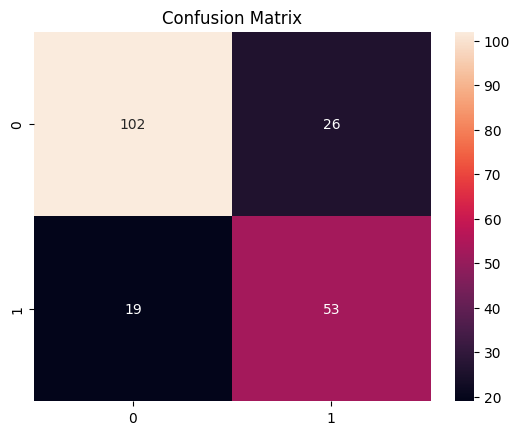

In [ ]:
cm_lr = confusion_matrix(tuned_y_pred_lr_s, y_test)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_lr_s.png")

In [ ]:
acc_lr_s    = accuracy_score(y_test, tuned_y_pred_lr_s)
prec_0_lr_s = precision_score(y_test, tuned_y_pred_lr_s, pos_label=0)
prec_1_lr_s = precision_score(y_test, tuned_y_pred_lr_s, pos_label=1)
rec_0_lr_s  = recall_score(y_test, tuned_y_pred_lr_s, pos_label=0)
rec_1_lr_s  = recall_score(y_test, tuned_y_pred_lr_s, pos_label=1)
f1_0_lr_s  = f1_score(y_test, tuned_y_pred_lr_s, pos_label=0)
f1_1_lr_s   = f1_score(y_test, tuned_y_pred_lr_s, pos_label=1)
y_pred_lr_p = tuned_model_lr_s.predict_proba(X_test)[:, 1]
roc_lr_s = roc_auc_score(y_test, y_pred_lr_p)

In [ ]:
print(roc_lr_s)

0.8401506433727377


In [ ]:
mlflow.set_experiment("credit_risk_classification")
best = grid_search_lr_s.best_params_

with mlflow.start_run(run_name = "Logistic Regression Tuned"):
  mlflow.log_param("model_type","LogisticRegression")
  mlflow.log_param("C", best["classifier__C"])
  mlflow.log_param("penalty", best["classifier__penalty"])
  mlflow.log_param("solver", best["classifier__solver"])
  mlflow.log_param("random_state", 42)
  mlflow.log_metric("accuracy", acc_lr_s)
  mlflow.log_metric("precision_class_0", prec_0_lr_s)
  mlflow.log_metric("precision_class_1", prec_1_lr_s)
  mlflow.log_metric("recall_class_0", rec_0_lr_s)
  mlflow.log_metric("recall_class_1", rec_1_lr_s)
  mlflow.log_metric("f1_score_0", f1_0_lr_s)
  mlflow.log_metric("f1_score_1", f1_1_lr_s)
  mlflow.log_metric("cv_score", grid_search_lr_s.best_score_)
  mlflow.log_artifact("confusion_matrix_lr_s.png")
  mlflow.sklearn.log_model(sk_model = tuned_model_lr_s,
                           name = "Logistic Regression Tuned Model")

2026/02/25 14:21:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/25 14:21:00 INFO mlflow.store.db.utils: Updating database tables
2026/02/25 14:21:01 INFO mlflow.tracking.fluent: Experiment with name 'credit_risk_classification' does not exist. Creating a new experiment.
2026/02/25 14:21:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<h2>Random Forest – Grid Search with Normal CV

Random Forest hyperparameters tuned include:

n_estimators

max_depth

min_samples_split

min_samples_leaf

Random Forest reduces overfitting through ensemble averaging, but individual tree depth still impacts model complexity. Normal CV evaluates performance across folds without enforcing class balance.

In [ ]:
param_grid = {
    'classifier__n_estimators': [50, 100, 150, 200, 250],
    'classifier__max_depth': [10, 20, 25, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_rf.fit(X_train, y_train)
print(f"Best params: {grid_search_rf.best_params_}")
print(f"Best CV score: {grid_search_rf.best_score_:.4f}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV score: 0.8085


<h2>Random Forest – Normal CV Best Parameters & Test Accuracy

After selecting optimal hyperparameters, the model is retrained and evaluated on the test set.

Very high training accuracy is expected for Random Forest due to its flexibility.

The difference between training and test accuracy indicates whether the model is overfitting.

In [ ]:
tuned_model_rf = grid_search_rf.best_estimator_
tuned_y_pred_rf = tuned_model_rf.predict(X_test)
accuracy_score_rf_tuned = accuracy_score(tuned_y_pred_rf, y_test)
print(f"Train Accuracy of Random Forest Classifier: {tuned_model_rf.score(X_train, y_train):.4f}")
print(f"Test Accuracy of Random Forest Classifier: {accuracy_score_rf_tuned} ")

Train Accuracy of Random Forest Classifier: 0.9387
Test Accuracy of Random Forest Classifier: 0.86 


<h2>Random Forest – Grid Search with Stratified K-Fold

Stratified cross-validation is applied to ensure balanced class distribution during tuning.

This is especially useful in classification tasks where minority classes must be properly represented in each fold.

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)
param_grid = {
    'classifier__n_estimators': [50, 100, 150, 200, 250],
    'classifier__max_depth': [10, 20, 25, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search_rf_s = GridSearchCV(
    rf_pipeline,
    param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_rf_s.fit(X_train, y_train)
print(f"Best params: {grid_search_rf_s.best_params_}")
print(f"Best CV score: {grid_search_rf_s.best_score_:.4f}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 250}
Best CV score: 0.8103


<h2>Random Forest – Stratified CV Best Parameters & Test Accuracy

The best stratified configuration is evaluated on the test set.

If test performance remains similar across validation methods, the model demonstrates stability.

Stratified validation generally provides a more reliable performance estimate.

In [ ]:
tuned_model_rf_s = grid_search_rf_s.best_estimator_
tuned_y_pred_rf_s = tuned_model_rf_s.predict(X_test)
accuracy_score_rf_tuned_s = accuracy_score(tuned_y_pred_rf_s, y_test)
print(f"Train Accuracy of Random Forest Classifier: {tuned_model_rf_s.score(X_train, y_train):.4f}")
print(f"Test Accuracy of Random Forest Classifier: {accuracy_score_rf_tuned_s} ")

Train Accuracy of Random Forest Classifier: 0.9988
Test Accuracy of Random Forest Classifier: 0.85 


In [ ]:
report_tuned_rf_s = classification_report(tuned_y_pred_rf_s, y_test)

print(report_tuned_rf_s)

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       129
           1       0.76      0.85      0.80        71

    accuracy                           0.85       200
   macro avg       0.83      0.85      0.84       200
weighted avg       0.86      0.85      0.85       200



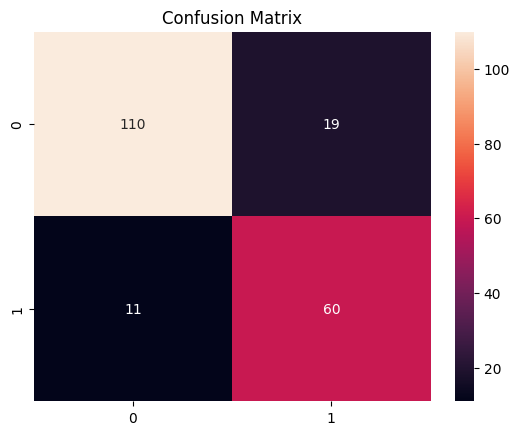

In [ ]:
cm_rf = confusion_matrix(tuned_y_pred_rf_s, y_test)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_rf_s.png")

In [ ]:
acc_rf_s    = accuracy_score(y_test, tuned_y_pred_rf_s)
prec_0_rf_s = precision_score(y_test, tuned_y_pred_rf_s, pos_label=0)
prec_1_rf_s = precision_score(y_test, tuned_y_pred_rf_s, pos_label=1)
rec_0_rf_s  = recall_score(y_test, tuned_y_pred_rf_s, pos_label=0)
rec_1_rf_s  = recall_score(y_test, tuned_y_pred_rf_s, pos_label=1)
f1_0_rf_s  = f1_score(y_test, tuned_y_pred_rf_s, pos_label=0)
f1_1_rf_s   = f1_score(y_test, tuned_y_pred_rf_s, pos_label=1)
y_pred_rf_p = tuned_model_rf_s.predict_proba(X_test)[:, 1]
roc_rf_s = roc_auc_score(y_test, y_pred_rf_p)

In [ ]:
print(roc_rf_s)

0.9249921539910032


In [ ]:
mlflow.set_experiment("credit_risk_classification")
best = grid_search_rf_s.best_params_

with mlflow.start_run(run_name = "Random Forest Tuned"):
  mlflow.log_param("model_type","RandomForest")
  mlflow.log_param("n_estimators", best["classifier__n_estimators"])
  mlflow.log_param("min_samples_leaf", best["classifier__min_samples_leaf"])
  mlflow.log_param("min_samples_split", best["classifier__min_samples_split"])
  mlflow.log_param("max_depth", best["classifier__max_depth"])
  mlflow.log_param("random_state", 42)
  mlflow.log_metric("accuracy", acc_rf_s)
  mlflow.log_metric("precision_class_0", prec_0_rf_s)
  mlflow.log_metric("precision_class_1", prec_1_rf_s)
  mlflow.log_metric("recall_class_0", rec_0_rf_s)
  mlflow.log_metric("recall_class_1", rec_1_rf_s)
  mlflow.log_metric("f1_score_0", f1_0_rf_s)
  mlflow.log_metric("f1_score_1", f1_1_rf_s)
  mlflow.log_metric("cv_score", grid_search_rf_s.best_score_)
  mlflow.log_artifact("confusion_matrix_rf_s.png")
  mlflow.sklearn.log_model(sk_model = tuned_model_rf_s,
                           name = "Random Forest Tuned Model")

2026/02/25 14:29:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<h2>Decision Tree – Grid Search with Normal CV

For the Decision Tree model, hyperparameters such as

max_depth,

min_samples_split,

min_samples_leaf

criterion

are tuned using standard K-Fold cross-validation.
These parameters directly influence model complexity and overfitting behavior. Normal CV evaluates different splits but does not enforce class balance.

In [ ]:
param_grid = {
    'classifier__max_depth': [10, 20, 25, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion':["gini","entropy"]
}

grid_search_dt = GridSearchCV(
    dt_pipeline,
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_dt.fit(X_train, y_train)
print(f"Best params: {grid_search_dt.best_params_}")
print(f"Best CV score: {grid_search_dt.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best CV score: 0.7797


<h2>Decision Tree – Normal CV Best Parameters & Test Accuracy

The optimal Decision Tree configuration is selected based on cross-validation performance and then evaluated on the test set.

A high training score combined with lower test accuracy indicates overfitting.

The goal is to find a depth and split configuration that balances bias and variance.

In [ ]:
tuned_model_dt = grid_search_dt.best_estimator_
tuned_y_pred_dt = tuned_model_dt.predict(X_test)
accuracy_score_dt_tuned = accuracy_score(tuned_y_pred_dt, y_test)
print(f"Train Accuracy of Decision Tree Classifier: {tuned_model_dt.score(X_train, y_train):.4f}")
print(f"Test Accuracy of Decision Tree Classifier: {accuracy_score_dt_tuned} ")

Train Accuracy of Decision Tree Classifier: 0.9625
Test Accuracy of Decision Tree Classifier: 0.805 


<h2>Decision Tree – Grid Search with Stratified K-Fold

Stratified cross-validation ensures that each fold contains a representative distribution of target classes.

For a model like Decision Tree, which can be sensitive to data distribution, stratification provides a more stable tuning process.

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)
param_grid = {
    'classifier__max_depth': [10, 20, 25, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion':["gini","entropy"]
}

grid_search_dt_s = GridSearchCV(
    dt_pipeline,
    param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_dt_s.fit(X_train, y_train)
print(f"Best params: {grid_search_dt_s.best_params_}")
print(f"Best CV score: {grid_search_dt_s.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}
Best CV score: 0.7741


<h2>Decision Tree – Stratified CV Best Parameters & Test Accuracy

The Decision Tree is retrained using the best parameters found through stratified validation.

If stratified CV results in slightly different hyperparameters or test performance, it reflects the effect of balanced validation splits. Consistency between both methods indicates robustness.

In [ ]:
tuned_model_dt_s = grid_search_dt_s.best_estimator_
tuned_y_pred_dt_s = tuned_model_dt_s.predict(X_test)
accuracy_score_dt_tuned_s = accuracy_score(tuned_y_pred_dt_s, y_test)
print(f"Train Accuracy of Decision Tree Classifier: {tuned_model_dt_s.score(X_train, y_train):.4f}")
print(f"Test Accuracy of Decision Tree Classifier: {accuracy_score_dt_tuned_s} ")

Train Accuracy of Decision Tree Classifier: 0.9275
Test Accuracy of Decision Tree Classifier: 0.82 


In [ ]:
report_tuned_dt_s = classification_report(tuned_y_pred_dt_s, y_test)

print(report_tuned_dt_s)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       113
           1       0.82      0.75      0.78        87

    accuracy                           0.82       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.82      0.82       200



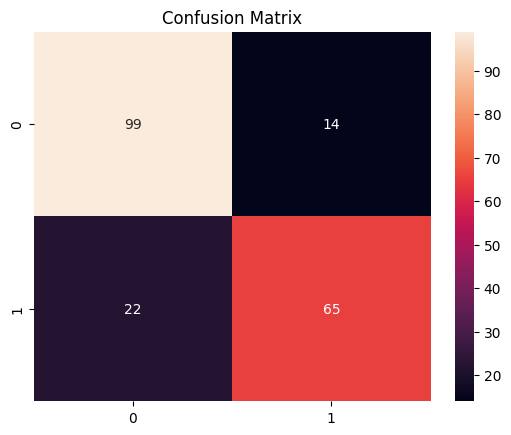

In [ ]:
cm_dt = confusion_matrix(tuned_y_pred_dt_s, y_test)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_dt_s.png")

In [ ]:
acc_dt_s    = accuracy_score(y_test, tuned_y_pred_dt_s)
prec_0_dt_s = precision_score(y_test, tuned_y_pred_dt_s, pos_label=0)
prec_1_dt_s = precision_score(y_test, tuned_y_pred_dt_s, pos_label=1)
rec_0_dt_s  = recall_score(y_test, tuned_y_pred_dt_s, pos_label=0)
rec_1_dt_s  = recall_score(y_test, tuned_y_pred_dt_s, pos_label=1)
f1_0_dt_s  = f1_score(y_test, tuned_y_pred_dt_s, pos_label=0)
f1_1_dt_s   = f1_score(y_test, tuned_y_pred_dt_s, pos_label=1)
y_pred_dt_p = tuned_model_dt_s.predict_proba(X_test)[:, 1]
roc_dt_s = roc_auc_score(y_test, y_pred_dt_p)

In [ ]:
print(roc_dt_s)

0.8691285699340934


In [ ]:
mlflow.set_experiment("credit_risk_classification")
best = grid_search_dt_s.best_params_

with mlflow.start_run(run_name = "Decision Tree Tuned"):
  mlflow.log_param("model_type","DecisionTree")
  mlflow.log_param("criterion", best["classifier__criterion"])
  mlflow.log_param("min_samples_leaf", best["classifier__min_samples_leaf"])
  mlflow.log_param("min_samples_split", best["classifier__min_samples_split"])
  mlflow.log_param("max_depth", best["classifier__max_depth"])
  mlflow.log_param("random_state", 42)
  mlflow.log_metric("accuracy", acc_dt_s)
  mlflow.log_metric("precision_class_0", prec_0_dt_s)
  mlflow.log_metric("precision_class_1", prec_1_dt_s)
  mlflow.log_metric("recall_class_0", rec_0_dt_s)
  mlflow.log_metric("recall_class_1", rec_1_dt_s)
  mlflow.log_metric("f1_score_0", f1_0_dt_s)
  mlflow.log_metric("f1_score_1", f1_1_dt_s)
  mlflow.log_metric("cv_score", grid_search_dt_s.best_score_)
  mlflow.log_artifact("confusion_matrix_dt_s.png")
  mlflow.sklearn.log_model(sk_model = tuned_model_dt_s,
                           name = "Decision Tree Tuned Model")

2026/02/25 14:31:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<h2>XGBoost – Grid Search with Normal CV

XGBoost tuning focuses on:

max_depth

learning_rate

n_estimators

Since XGBoost builds trees sequentially, controlling depth and learning rate is essential to prevent overfitting. Normal K-Fold is used to estimate performance across multiple partitions.

In [ ]:
param_grid = {
    'classifier__max_depth': [3, 7, 10, 15, 20],
    'classifier__learning_rate': [0.0001, 0.001, 0.01, 0.1, 1],
    'classifier__n_estimators':[100, 150, 200, 250],
}

grid_search_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_xgb.fit(X_train, y_train)
print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best CV score: {grid_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV score: 0.8241


<h2>XGBoost – Normal CV Best Parameters & Test Accuracy

The tuned XGBoost model is retrained and evaluated on the test set.

Because boosting models are highly flexible, they often achieve high training accuracy.

The test accuracy reflects how well boosting generalizes beyond training data.

In [ ]:
tuned_model_xgb = grid_search_xgb.best_estimator_
tuned_y_pred_xgb = tuned_model_xgb.predict(X_test)
accuracy_score_xgb_tuned = accuracy_score(tuned_y_pred_xgb, y_test)
print(f"Train Accuracy of XG Boost Classifier: {tuned_model_xgb.score(X_train, y_train):.4f}")
print(f"Test Accuracy of XG Boost Classifier: {accuracy_score_xgb_tuned} ")

Train Accuracy of XG Boost Classifier: 0.9350
Test Accuracy of XG Boost Classifier: 0.875 


<h2>XGBoost – Grid Search with Stratified K-Fold

Stratified cross-validation ensures consistent class proportions during boosting parameter selection. This improves the reliability of validation results in classification tasks.

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)
param_grid = {
    'classifier__max_depth': [3, 7, 10, 15, 20],
    'classifier__learning_rate': [0.0001, 0.001, 0.01, 0.1, 1],
    'classifier__n_estimators':[100, 150, 200, 250]
}

grid_search_xgb_s = GridSearchCV(
    xgb_pipeline,
    param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_xgb_s.fit(X_train, y_train)
print(f"Best params: {grid_search_xgb_s.best_params_}")
print(f"Best CV score: {grid_search_xgb_s.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 150}
Best CV score: 0.8296


<h2>XGBoost – Stratified CV Best Parameters & Test Accuracy

The final XGBoost model is trained using the best stratified parameters and evaluated on the test set.

Comparing normal and stratified results helps assess model stability. Small differences suggest robustness, while larger differences indicate sensitivity to validation strategy.

In [ ]:
tuned_model_xgb_s = grid_search_xgb_s.best_estimator_
tuned_y_pred_xgb_s = tuned_model_xgb_s.predict(X_test)
accuracy_score_xgb_tuned_s = accuracy_score(tuned_y_pred_xgb_s, y_test)
print(f"Train Accuracy of XG Boost Classifier: {tuned_model_xgb_s.score(X_train, y_train):.4f}")
print(f"Test Accuracy of XG Boost Classifier: {accuracy_score_xgb_tuned_s} ")

Train Accuracy of XG Boost Classifier: 0.9487
Test Accuracy of XG Boost Classifier: 0.875 


In [ ]:
report_tuned_xgb_s = classification_report(tuned_y_pred_xgb_s, y_test)

print(report_tuned_xgb_s)

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       124
           1       0.82      0.86      0.84        76

    accuracy                           0.88       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.88      0.88      0.88       200



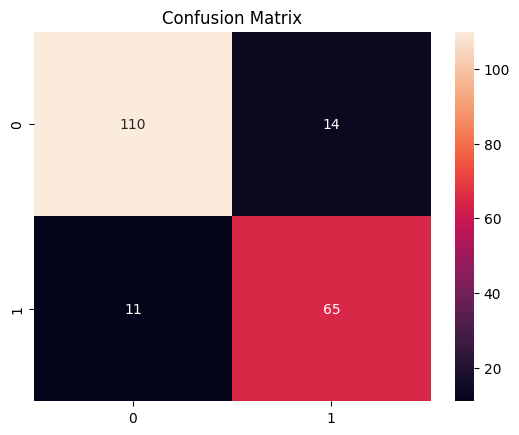

In [ ]:
cm_xgb = confusion_matrix(tuned_y_pred_xgb_s, y_test)

plt.figure()
sns.heatmap(cm_xgb, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_xgb_s.png")

In [ ]:
acc_xgb_s    = accuracy_score(y_test, tuned_y_pred_xgb_s)
prec_0_xgb_s = precision_score(y_test, tuned_y_pred_xgb_s, pos_label=0)
prec_1_xgb_s = precision_score(y_test, tuned_y_pred_xgb_s, pos_label=1)
rec_0_xgb_s  = recall_score(y_test, tuned_y_pred_xgb_s, pos_label=0)
rec_1_xgb_s  = recall_score(y_test, tuned_y_pred_xgb_s, pos_label=1)
f1_0_xgb_s  = f1_score(y_test, tuned_y_pred_xgb_s, pos_label=0)
f1_1_xgb_s   = f1_score(y_test, tuned_y_pred_xgb_s, pos_label=1)
y_pred_xgb_p = tuned_model_xgb_s.predict_proba(X_test)[:, 1]
roc_xgb_s = roc_auc_score(y_test, y_pred_xgb_p)

In [ ]:
print(roc_xgb_s)

0.9407887854378073


In [ ]:
mlflow.set_experiment("credit_risk_classification")
best = grid_search_xgb_s.best_params_

with mlflow.start_run(run_name = "XGB Tuned"):
  mlflow.log_param("model_type","XGBoost")
  mlflow.log_param("n_estimators", best["classifier__n_estimators"])
  mlflow.log_param("max_depth", best["classifier__max_depth"])
  mlflow.log_param("learning_rate", best["classifier__learning_rate"])
  mlflow.log_param("random_state", 42)
  mlflow.log_metric("accuracy", acc_xgb_s)
  mlflow.log_metric("precision_class_0", prec_0_xgb_s)
  mlflow.log_metric("precision_class_1", prec_1_xgb_s)
  mlflow.log_metric("recall_class_0", rec_0_xgb_s)
  mlflow.log_metric("recall_class_1", rec_1_xgb_s)
  mlflow.log_metric("f1_score_0", f1_0_xgb_s)
  mlflow.log_metric("f1_score_1", f1_1_xgb_s)
  mlflow.log_metric("cv_score", grid_search_xgb_s.best_score_)
  mlflow.log_artifact("confusion_matrix_xgb_s.png")
  mlflow.sklearn.log_model(tuned_model_xgb_s, "XGB Tuned Model")

2026/02/25 14:34:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 14:34:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<h2> Why Stratified K-Fold is preferred over Normal K-Fold

Since this is a classification problem, the distribution of the target classes (Good vs Bad credit) is important during the validation process. If we perform normal K-Fold cross-validation, the data will be split randomly without making sure that each fold has a balanced split of both classes.

This might someitmes result in a situatuon where one class has a higher  representation, and the other has a lower representation in a particular fold, which might result in incorrect validation results.

This issue is resolved by the stratified K-fold, which makes sure that each fold retains the original class distribution. This indicates that the Good and Bad credit representations in each fold are identical to those in the original dataset.

The following benefits come from using stratified cross-validation:

For validation, it offers a moe reliable and consistent outcome.

It eliminates the randomness caused by unequal class divisions.

It offers a more accurate assesment of the model's performance.

The use of stratified cross-validation gaurantees a more accurate validation process because credit risk prediction is a binary classification problem.

<div style="font-size:18px">

| Model | Pre Train | Pre Test | Pre F1 | Pre Gap | Post CV | Post Train | Post Test | Post F1 | Post Gap |
|--------|-----------|----------|--------|---------|----------|------------|-----------|----------|----------|
| Logistic Regression | 0.84 | 0.83 | 0.83 | 0.01 | 0.83 | 0.84 | 0.83 | 0.83 | 0.01 |
| Decision Tree | 0.95 | 0.82 | 0.81 | 0.13 | 0.77 | 0.94 | 0.81 | 0.80 | 0.13 |
| Random Forest | 1.00 | 0.85 | 0.85 | 0.15 | 0.87 | 0.99 | 0.86 | 0.86 | 0.13 |
| XGBoost | 1.00 | 0.88 | 0.84 | 0.12 | 0.89 | 0.98 | 0.88 | 0.84 | 0.10 |

</div>


# Saving the models

In [ ]:
joblib.dump(tuned_model_lr_s, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/logistic_regression.pkl")
joblib.dump(tuned_model_rf_s, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/random_forest.pkl")
joblib.dump(tuned_model_dt_s, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/decision_tree.pkl")
joblib.dump(tuned_model_xgb_s, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/xgboost.pkl")

['/content/drive/MyDrive/T2_Project_Kuvam_Sharma/Models/xgboost.pkl']

In [ ]:
metrics_dict = {
    "XGBoost": {
        "accuracy": acc_xgb_s,
        "precision_class0": prec_0_xgb_s,
        "precision_class1": prec_1_xgb_s,
        "recall_class0": rec_0_xgb_s,
        "recall_class1": rec_1_xgb_s,
        "f1_class0": f1_0_xgb_s,
        "f1_class1": f1_1_xgb_s,
        "roc_auc": roc_xgb_s,
        "classification_report_xgb": report_tuned_xgb_s,
        "confusion_matrix": cm_xgb
    },
    "DecisionTree": {
        "accuracy": acc_dt_s,
        "precision_class0": prec_0_dt_s,
        "precision_class1": prec_1_dt_s,
        "recall_class0": rec_0_dt_s,
        "recall_class1": rec_1_dt_s,
        "f1_class0": f1_0_dt_s,
        "f1_class1": f1_1_dt_s,
        "roc_auc": roc_dt_s,
        "classification_report_dt": report_tuned_dt_s,
        "confusion_matrix": cm_dt
    },
    "RandomForest": {
        "accuracy": acc_rf_s,
        "precision_class0": prec_0_rf_s,
        "precision_class1": prec_1_rf_s,
        "recall_class0": rec_0_rf_s,
        "recall_class1": rec_1_rf_s,
        "f1_class0": f1_0_rf_s,
        "f1_class1": f1_1_rf_s,
        "roc_auc": roc_rf_s,
        "classification_report_rf": report_tuned_rf_s,
        "confusion_matrix": cm_rf
    },
    "LogisticRegression": {
        "accuracy": acc_lr_s,
        "precision_class0": prec_0_lr_s,
        "precision_class1": prec_1_lr_s,
        "recall_class0": rec_0_lr_s,
        "recall_class1": rec_1_lr_s,
        "f1_class0": f1_0_lr_s,
        "f1_class1": f1_1_lr_s,
        "roc_auc": roc_lr_s,
        "classification_report_lr": report_tuned_lr_s,
        "confusion_matrix": cm_lr
    }
}

joblib.dump(metrics_dict, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Evaluation_Metrics/all_model_metrics.pkl")

['/content/drive/MyDrive/T2_Project_Kuvam_Sharma/Evaluation_Metrics/all_model_metrics.pkl']